In [1]:
import numpy as np
from scipy.stats import beta, norm

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
alpha_prior, beta_prior = 1, 1
n, y = 5, 3
alpha_post = alpha_prior + y
beta_post = beta_prior + (n - y)

In [3]:
def kl_normal_beta(mu, sigma, alpha, beta_param, n_samples=100_000):
    """
    KL divergence KL(N(mu, sigma^2) || Beta(alpha, beta_param))
    Computed by Monte Carlo integration.
    """
    # Sample from Normal
    samples = np.random.normal(mu, sigma, size=n_samples)
    # Restrict to [0,1] domain of Beta
    samples = samples[(samples >= 0) & (samples <= 1)]
    # Evaluate densities
    q_vals = norm.pdf(samples, mu, sigma)
    p_vals = beta.pdf(samples, alpha, beta_param)
    # Avoid log(0)
    mask = (p_vals > 0) & (q_vals > 0)
    q_vals = q_vals[mask]
    p_vals = p_vals[mask]
    return np.mean(np.log(q_vals) - np.log(p_vals))

In [36]:
mu_far, sigma_far = 0.3, 0.05
kl_far = kl_normal_beta(mu_far, sigma_far, alpha_post, beta_post)

# Good fit
mu_good, sigma_good = 0.5645, 0.1858
kl_good = kl_normal_beta(mu_good, sigma_good, alpha_post, beta_post)

kl_far, kl_good

(np.float64(1.8560090345534435), np.float64(0.016230349793764757))

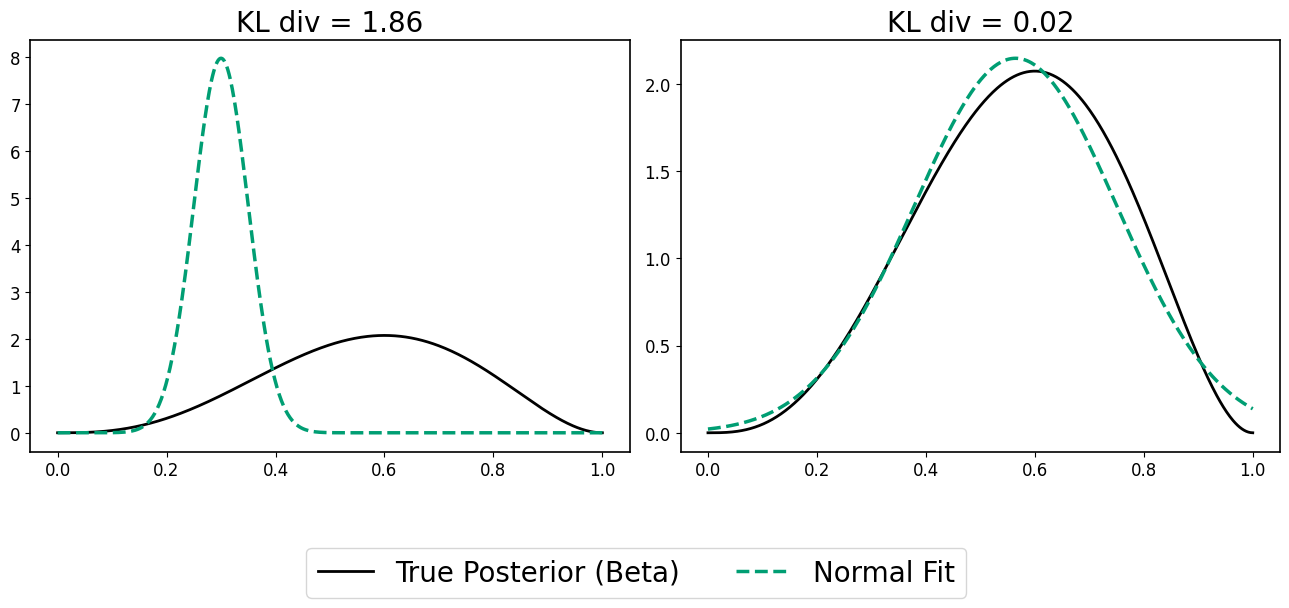

In [37]:
theta_vals = np.linspace(0, 1, 500)
beta_pdf = beta.pdf(theta_vals, alpha_post, beta_post)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# Posterior
ax[0].plot(theta_vals, beta_pdf, label="True Posterior (Beta)", color="k", lw=2)
ax[1].plot(theta_vals, beta_pdf, label="True Posterior (Beta)", color="k", lw=2)

# Far normal
ax[0].plot(theta_vals, norm.pdf(theta_vals, mu_far, sigma_far),
           color="C1", linestyle="--")
ax[0].set_title(f"KL div = {kl_far:.2f}", fontsize=20)

# Good normal
ax[1].plot(theta_vals, norm.pdf(theta_vals, mu_good, sigma_good),
         label=f"Normal Fit", color="C1", linestyle="--")
ax[1].set_title(f"KL div = {kl_good:.2f}", fontsize=20)

plt.tight_layout()
plt.legend(ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=20)
plt.show()